# alyx-data — Stage 2: General analysis

Working notebook for the Stage 2 deliverable. Loads the three layered
artifacts produced by Stage 1 (`docs/data-schema.md`) and walks through
the analyses that will populate `docs/general-analysis-2026-05-01.md`.

Section order mirrors the report skeleton:

1. **Setup** — env + corpus inventory + drift table vs predecessor.
2. **Carry-over from `findings-2026-04-22.md`** — refresh on the new corpus.
3. **NEW Layer 2 analyses** — trajectory shapes, tool calls, failure shapes,
   router transitions, multi-turn arcs, internal-vs-external diff.
4. **Stage 3 framing** — what the data implies for use-case identification.

Each cell that produces a numeric claim or chart for the report is marked
with a `# REPORT:` comment so the report write-up phase can grep for them.

Plan: `stages/2-general-analysis/plan.md`. Stage 1 sanity numbers we should
reproduce here: 400,560 raw spans → 25,464 flagged queries → 13,732 sessions;
internal share 45.4%; errored sessions 8.0%.

## 1. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "src" / "pipeline").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd  # noqa: E402

from analysis import detectors, loaders, plots  # noqa: E402

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

print("project root:", PROJECT_ROOT)
print("pandas:", pd.__version__)

project root: /Users/elizabethhutton/Projects/phoenix-clones/alyx-data/alyx-data
pandas: 2.3.3


In [2]:
# Layer 1 — flagged user queries. Small (~10 MB), load fully.
queries = loaders.load_queries()
ext_q = queries.loc[~queries['is_internal']]

# Layer 2b — sessions. Small (~5 MB), load fully.
sessions = loaders.load_sessions()

# Layer 2a — spans. ~600 MB on the 90d corpus; project to a slim set.
spans_slim_cols = (
    "session_id", "trace_id", "span_id", "parent_id",
    "name", "kind",
    "start_time", "end_time", "duration_ms",
    "status_code", "has_error", "error",
    "tool_name", "llm_model",
    "user_id", "user_email", "org_name",
)
spans = loaders.load_spans(columns=spans_slim_cols)
# Stage 1 schema gotcha: ``tool_name`` is empty for Alyx tool spans;
# the actual tool name lives on the span ``name``. Add a derived column.
spans = spans.assign(_tool=loaders.derive_tool_name(spans))

# Stable per-session derived column we'll reuse below.
sessions = sessions.assign(first_router=detectors.first_router(sessions))

# Per-session tool-call counts (using the derived tool name).
tool_per_session = (
    spans.loc[spans["_tool"].notna()]
    .groupby('session_id').size().rename('tool_calls')
)

print("queries:", queries.shape, " external:", len(ext_q))
print("sessions:", sessions.shape, " multi-turn:", int((sessions['turn_count'] >= 2).sum()))
print("spans:", spans.shape, " named tool spans:", int(spans['_tool'].notna().sum()))

queries: (25464, 22)  external: 13910
sessions: (13732, 17)  multi-turn: 5975
spans: (400560, 18)  named tool spans: 148281


In [3]:
# REPORT: corpus inventory + Stage 1 sanity check.
manifest = loaders.load_raw_manifest()
raw_chunks = manifest.get("chunks", []) or []
raw_total = sum((c.get("rows", 0) for c in raw_chunks), 0)
alyx_spans = loaders.alyx_only_spans(spans)

summary = pd.DataFrame(
    [
        ("Layer 0  raw spans",                  raw_total,            f"{len(raw_chunks)} chunks"),
        ("Layer 1  user queries (flagged)",     len(queries),         "only is_empty hard-dropped at L1"),
        ("Layer 1  is_internal",                int(queries['is_internal'].sum()),       f"{queries['is_internal'].mean():.1%} of queries"),
        ("Layer 1  is_seed_button_match",       int(queries['is_seed_button_match'].sum()), f"{queries['is_seed_button_match'].mean():.1%} of queries"),
        ("Layer 2  spans (Alyx-only)",          len(alyx_spans),      "non-Alyx noise dropped"),
        ("Layer 2  sessions",                   len(sessions),        "one row per session.id"),
        ("Layer 2  errored sessions",           int((sessions['error_count'] > 0).sum()), f"{(sessions['error_count'] > 0).mean():.1%} of sessions"),
    ],
    columns=["layer", "count", "note"],
)
summary

,layer,count,note
0,Layer 0 raw spans,400560,7 chunks
1,Layer 1 user queries (flagged),25464,only is_empty hard-dropped at L1
2,Layer 1 is_internal,11554,45.4% of queries
3,Layer 1 is_seed_button_match,4768,18.7% of queries
4,Layer 2 spans (Alyx-only),283313,non-Alyx noise dropped
5,Layer 2 sessions,13732,one row per session.id
6,Layer 2 errored sessions,1100,8.0% of sessions


### 1.1 Drift table vs predecessor (`findings-2026-04-22.md`)

Per the plan's verification gate: a refresh number diverging by **>20%**
from the predecessor's needs to be investigated and explained in the
report. This cell collects every comparable headline number side-by-side.

In [4]:
# REPORT: drift vs predecessor `findings-2026-04-22.md`.
rows = [
    ("Raw spans",                          388_420,  raw_total),
    ("Layer 1 queries (kept)",             24_733,   len(queries)),
    ("Internal share %",                   50.0,     queries['is_internal'].mean() * 100),
    ("PROMPT_OPTIMIZATION raw %",          32.0,     (queries['router_type'] == 'PROMPT_OPTIMIZATION').mean() * 100),
    ("CHAT raw %",                         19.0,     (queries['router_type'] == 'CHAT').mean() * 100),
    ("HOME_PAGE raw %",                    12.0,     (queries['router_type'] == 'HOME_PAGE').mean() * 100),
    ("TRACE_AGENT raw %",                  11.0,     (queries['router_type'] == 'TRACE_AGENT').mean() * 100),
    ("SEARCH raw %",                        9.0,     (queries['router_type'] == 'SEARCH').mean() * 100),
    ("PROMPT_OPTIMIZATION external %",     15.0,     (ext_q['router_type'] == 'PROMPT_OPTIMIZATION').mean() * 100),
    ("CHAT external %",                    20.0,     (ext_q['router_type'] == 'CHAT').mean() * 100),
    ("SEARCH external %",                  18.0,     (ext_q['router_type'] == 'SEARCH').mean() * 100),
    ("TRACE_AGENT external %",             16.0,     (ext_q['router_type'] == 'TRACE_AGENT').mean() * 100),
    ("Single-turn share %",                53.0,     (sessions['turn_count'] == 1).mean() * 100),
    ("2-3 turn share %",                   28.0,     (sessions['turn_count'].between(2, 3)).mean() * 100),
    ("4-7 turn share %",                   12.0,     (sessions['turn_count'].between(4, 7)).mean() * 100),
    ("8+ turn share %",                     6.0,     (sessions['turn_count'] >= 8).mean() * 100),
    ("Naked-identifier share %",            0.5,     queries['is_naked_identifier'].mean() * 100),
    ("Seed-button-match share %",           5.4,     queries['is_seed_button_match'].mean() * 100),
    ("April internal share %",             42.1,     queries.loc[pd.to_datetime(queries['timestamp'], utc=True).dt.month == 4, 'is_internal'].mean() * 100),
]
drift = pd.DataFrame(rows, columns=["metric", "predecessor", "current"])
drift["delta_pct"] = (drift["current"] - drift["predecessor"]) / drift["predecessor"] * 100
drift["flag"] = drift["delta_pct"].abs().gt(20).map({True: "⚠ >20%", False: ""})
drift

,metric,predecessor,current,delta_pct,flag
0,Raw spans,388420.0,400560.000000,3.125483,
1,Layer 1 queries (kept),24733.0,25464.000000,2.955565,
2,Internal share %,50.0,45.373861,-9.252278,
3,PROMPT_OPTIMIZATION raw %,32.0,27.324851,-14.609841,
4,CHAT raw %,19.0,19.286051,1.505531,
5,HOME_PAGE raw %,12.0,14.868049,23.900408,⚠ >20%
6,TRACE_AGENT raw %,11.0,10.834904,-1.500871,
7,SEARCH raw %,9.0,11.188344,24.314937,⚠ >20%
8,PROMPT_OPTIMIZATION external %,15.0,15.032351,0.215672,
9,CHAT external %,20.0,18.842559,-5.787203,


## 2. Carry-over analyses (refresh on the new corpus)

### 2.1 Router-type taxonomy

In [5]:
# REPORT: router-type taxonomy table — raw % vs external-only %.
router_total = queries["router_type"].value_counts(dropna=False)
router_ext = ext_q["router_type"].value_counts(dropna=False)
router_table = pd.DataFrame(
    {
        "raw_count": router_total,
        "raw_pct": router_total / router_total.sum(),
        "external_count": router_ext,
        "external_pct": router_ext / router_ext.sum(),
    }
).sort_values("raw_count", ascending=False)
router_table.head(20)

,raw_count,raw_pct,external_count,external_pct
router_type,,,,
PROMPT_OPTIMIZATION,6958,0.273249,2091,0.150324
CHAT,4911,0.192861,2621,0.188426
HOME_PAGE,3786,0.148680,2415,0.173616
SEARCH,2849,0.111883,2563,0.184256
TRACE_AGENT,2759,0.108349,1891,0.135945
CUSTOM_EVAL,1701,0.066800,712,0.051186
EXPERIMENT_SUMMARY,1180,0.046340,909,0.065349
AQL,667,0.026194,481,0.034579
TASK_PAGE,577,0.022659,175,0.012581


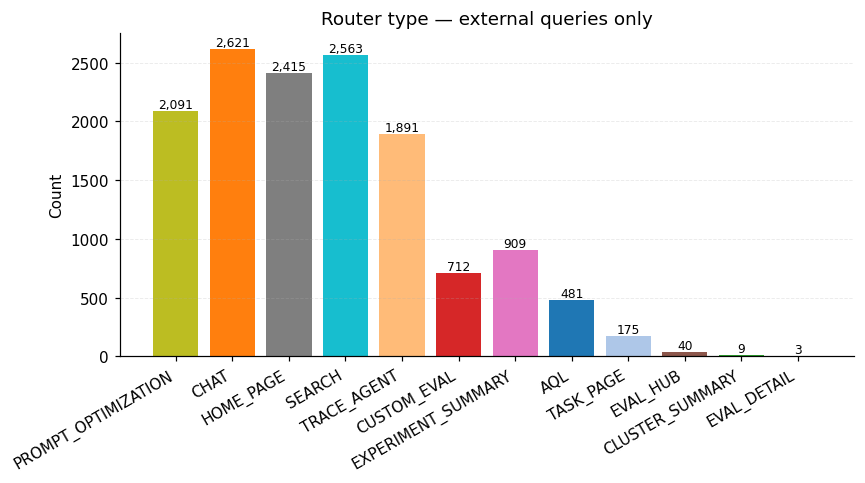

In [6]:
# REPORT: bar chart of external-only router distribution.
router_palette = plots.palette([str(x) for x in router_table.index.dropna()])
_, _ = plots.bar_counts(
    router_table["external_count"].dropna().astype(int),
    title="Router type — external queries only",
    color_map=router_palette,
)

### 2.2 Volume / growth over time

In [7]:
# REPORT: weekly external-query volume.
ts = pd.to_datetime(queries["timestamp"], utc=True)
weekly_ext = (
    queries.assign(week=ts.dt.tz_convert(None).dt.to_period("W-MON"))
    .loc[lambda d: ~d["is_internal"]]
    .groupby("week")
    .size()
    .rename("external_queries")
)
weekly_ext

week
2026-01-27/2026-02-02      50
2026-02-03/2026-02-09     561
2026-02-10/2026-02-16     992
2026-02-17/2026-02-23     877
2026-02-24/2026-03-02     692
2026-03-03/2026-03-09     893
2026-03-10/2026-03-16     977
2026-03-17/2026-03-23     952
2026-03-24/2026-03-30    1370
2026-03-31/2026-04-06    1237
2026-04-07/2026-04-13    1170
2026-04-14/2026-04-20    1626
2026-04-21/2026-04-27    1549
2026-04-28/2026-05-04     964
Freq: W-MON, Name: external_queries, dtype: int64

In [8]:
# REPORT: internal vs external split, by month.
monthly = (
    queries.assign(month=ts.dt.tz_convert(None).dt.to_period("M"))
    .groupby(["month", "is_internal"])
    .size()
    .unstack("is_internal", fill_value=0)
    .rename(columns={False: "external", True: "internal"})
)
monthly["internal_pct"] = monthly["internal"] / monthly.sum(axis=1)
monthly

is_internal,external,internal,internal_pct
month,,,
2026-01,0,12,1.000000
2026-02,2993,2924,0.494169
2026-03,4631,4447,0.489866
2026-04,6123,4108,0.401525
2026-05,163,63,0.278761


### 2.3 Customer segments — top external orgs

In [9]:
# REPORT: top external orgs by volume.
top_orgs = (
    ext_q.groupby("org_name", dropna=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
)
top_orgs

org_name
Disney                844
UKG                   478
Booking.com - PROD    290
stg                   243
Resmed                217
Agentic EOR           201
Prod                  176
Quizlet POC           161
Euna Solutions        132
RadiantSecurity       126
Fitch Group POC       119
Spekit                119
Absorb                116
Deloitte              108
DoorDash              101
dtype: int64

In [10]:
# REPORT: per-org router distribution for the top orgs.
org_router = (
    ext_q.loc[ext_q["org_name"].isin(top_orgs.head(8).index)]
    .groupby(["org_name", "router_type"])
    .size()
    .unstack(fill_value=0)
)
org_router_share = org_router.div(org_router.sum(axis=1).replace(0, pd.NA), axis=0)
(org_router_share * 100).round(0).fillna(0).astype(int)

router_type,AQL,CHAT,CUSTOM_EVAL,PROMPT_OPTIMIZATION,SEARCH,TASK_PAGE,TRACE_AGENT
org_name,,,,,,,
Agentic EOR,7,22,1,0,14,7,48
Booking.com - PROD,1,11,0,0,80,0,8
Disney,11,32,4,1,21,1,30
Prod,0,19,10,0,67,0,4
Quizlet POC,2,36,1,0,55,3,2
Resmed,37,34,8,0,4,4,12
UKG,0,44,1,0,36,0,19
stg,16,32,10,0,9,6,27


### 2.4 Session structure (turn-count distribution)

In [11]:
# REPORT: turn-count distribution. Predecessor: 53% single-turn.
bins = [0, 1, 2, 3, 7, 19, 1_000_000]
labels = ["1", "2", "3", "4-7", "8-19", "20+"]
turn_buckets = pd.cut(sessions["turn_count"], bins=bins, labels=labels, right=True)
turn_dist = turn_buckets.value_counts().sort_index()
turn_share = turn_dist / turn_dist.sum()
longest = sessions.nlargest(5, "turn_count")[["session_id", "turn_count", "span_count", "is_internal", "first_router"]]
print("longest sessions:")
print(longest.to_string(index=False))
print()
pd.DataFrame({"sessions": turn_dist, "share": turn_share})

longest sessions:
session_id  turn_count  span_count  is_internal        first_router
     37143         152        1884        False         TRACE_AGENT
     31529         124         595        False         TRACE_AGENT
     40126         117        1264        False                 AQL
     30749          69         663        False PROMPT_OPTIMIZATION
     31702          69         238        False                CHAT



,sessions,share
turn_count,,
1,7734,0.564155
2,3415,0.249106
3,976,0.071194
4-7,1155,0.084251
8-19,354,0.025822
20+,75,0.005471


### 2.5 Language diversity

In [12]:
# REPORT: pure-ASCII vs heavy-non-ASCII share. Predecessor: 226 heavy-non-ASCII.
def _non_ascii_share(s: str) -> float:
    if not s:
        return 0.0
    return sum(1 for ch in s if ord(ch) > 127) / len(s)

qt = queries["query_text"].fillna("").astype(str)
non_ascii_share = qt.map(_non_ascii_share)
pd.Series(
    {
        "pure_ascii": int((non_ascii_share == 0).sum()),
        "any_non_ascii": int((non_ascii_share > 0).sum()),
        "heavy_non_ascii (>30%)": int((non_ascii_share > 0.3).sum()),
    },
    name="queries",
)

pure_ascii                24051
any_non_ascii              1413
heavy_non_ascii (>30%)      180
Name: queries, dtype: int64

## 3. NEW analyses enabled by Layer 2

### 3.1 Trajectory shape per router type

First-turn router → avg span count, avg tool-call count, avg duration,
error rate. Uses the `first_router` column we attached in Setup.
*Prior version of this cell had a bug where ``isinstance(seq, (list, tuple))``
didn't match numpy arrays — output was empty. Fixed via `detectors.first_router`.*

In [13]:
# REPORT: trajectory shape per router type.
shape = (
    sessions.merge(tool_per_session, on='session_id', how='left')
    .assign(tool_calls=lambda d: d['tool_calls'].fillna(0).astype(int))
    .groupby("first_router", dropna=True)
    .agg(
        sessions=("session_id", "size"),
        avg_turns=("turn_count", "mean"),
        avg_spans=("span_count", "mean"),
        avg_tool_calls=("tool_calls", "mean"),
        median_duration_min=("duration_ms", lambda s: s.median() / 60_000),
        error_rate=("error_count", lambda s: float((s > 0).mean())),
    )
    .sort_values("sessions", ascending=False)
)
# Note: avg_duration is heavily skewed by long-running session_ids (users
# return to the same UI session days later). Median is much more honest.
shape.round(2)

,sessions,avg_turns,avg_spans,avg_tool_calls,median_duration_min,error_rate
first_router,,,,,,
PROMPT_OPTIMIZATION,4182,2.26,16.93,8.70,0.97,0.06
HOME_PAGE,2581,1.49,9.27,4.57,0.24,0.04
CHAT,2225,2.62,33.60,18.34,1.07,0.12
SEARCH,1212,2.38,30.47,15.09,0.47,0.05
CUSTOM_EVAL,1136,1.85,18.02,9.80,0.48,0.17
TRACE_AGENT,1061,2.80,27.44,14.12,0.45,0.08
EXPERIMENT_SUMMARY,624,2.19,24.07,12.71,1.12,0.15
TASK_PAGE,486,1.38,14.28,8.42,0.34,0.14
AQL,138,4.12,31.47,15.59,0.78,0.06


### 3.2 Tool-call patterns

*Stage 1 schema gotcha: `attributes.tool.name` is empty in Alyx
production data — the actual tool name lives on the span's top-level
`name` field. We pull it via `loaders.derive_tool_name`, which also
filters out the GraphQL-query spans that ride under the same OTel
context (kind=TOOL, name=`GQL query *`). See `notes.md` for the full
postmortem.*

In [14]:
# REPORT: top tool names overall — derived from span `name`, not `tool_name`.
tool_spans = spans.loc[spans["_tool"].notna()]
tool_top = tool_spans["_tool"].value_counts().head(20)
print(f"named Alyx tool calls: {len(tool_spans):,} / {(spans['kind'] == 'TOOL').sum():,} TOOL spans")
print(f"  (GQL spans + un-named tool spans excluded)")
tool_top

named Alyx tool calls: 148,281 / 252,539 TOOL spans
  (GQL spans + un-named tool spans excluded)


_tool
finish                      21311
todo_update                 18167
playground_agent             9423
jq                           8483
todo_write                   6113
get_traces_table_preview     5719
validate_filter              5412
traces_agent                 5155
get_spans                    4883
get_model_columns            4216
home_page_agent              3849
search_bar_agent             2853
link_to_page                 2549
get_dataset_preview          2518
finalize_filter              2262
traces_page_agent            2174
get_dimension_values         2154
eval_agent                   2144
update_playground_prompt     1950
build_eval                   1508
Name: count, dtype: int64

In [15]:
# REPORT: tool-name frequencies broken down by first router.
session_router = sessions[["session_id", "first_router"]].dropna()
tool_by_router = (
    tool_spans.merge(session_router, on="session_id", how="inner")
    .groupby(["first_router", "_tool"])
    .size()
    .rename("calls")
    .reset_index()
    .sort_values(["first_router", "calls"], ascending=[True, False])
)
tool_by_router.groupby("first_router").head(5)

,first_router,_tool,calls
17,AQL,finish,457
9,AQL,custom_metrics_agent,338
18,AQL,generate_aql,250
21,AQL,get_model_columns,192
36,AQL,validate_filter,140
106,CHAT,todo_update,8251
68,CHAT,finish,4963
92,CHAT,get_traces_table_preview,4665
109,CHAT,traces_agent,3413
107,CHAT,todo_write,2526


### 3.3 Failure shapes

Three lenses, each independently useful for Pixie eval design:
1. **Errored sessions** — at least one span with `has_error=True`.
2. **Retry follow-ups** — short retry-shaped utterance after first turn.
3. **Truncated trajectories** — last span errored.

Plus per-router error-rate to see which surfaces are leakiest.

In [16]:
# REPORT: top error types overall.
errored_spans = spans.loc[spans["has_error"].fillna(False)].copy()
errored_spans["err_type"] = (
    errored_spans["error"].fillna("").str.split(":", n=1).str[0].str.strip()
)
err_top = errored_spans["err_type"].replace("", "<unspecified>").value_counts().head(15)
err_top

err_type
Recoverable exception              842
TransportQueryError                478
<unspecified>                      368
LLMProviderError                   366
ArizeHostedLLMProviderError        215
BadRequestError                    121
AuthenticationError                109
ToolNotFoundError (recoverable)    106
ValueError                          96
TransportConnectionFailed           92
ToolNotFoundError                   50
InternalServerError                 48
ContentPolicyViolationError         37
ContextWindowExceededError          36
AttributeError                      34
Name: count, dtype: int64

In [17]:
# REPORT: error rate by first router.
fail_by_router = (
    sessions.assign(errored=lambda d: d['error_count'] > 0)
    .groupby('first_router', dropna=True)
    .agg(sessions=('session_id','size'),
         errored_sessions=('errored','sum'),
         error_rate=('errored','mean'))
    .sort_values('error_rate', ascending=False)
)
fail_by_router.round(3)

,sessions,errored_sessions,error_rate
first_router,,,
CLUSTER_SUMMARY,24,6,0.250
CUSTOM_EVAL,1136,190,0.167
EXPERIMENT_SUMMARY,624,93,0.149
TASK_PAGE,486,68,0.140
CHAT,2225,261,0.117
TRACE_AGENT,1061,82,0.077
AQL,138,8,0.058
EVAL_HUB,36,2,0.056
PROMPT_OPTIMIZATION,4182,232,0.055


In [18]:
# REPORT: per-phrase retry counts on the corpus. Predecessor saw
# 26x "try again" from 18 distinct users on a slightly older 90d window.
retry_table = detectors.query_phrase_matches(queries, detectors.RETRY_PHRASES)
retry_table.head(12)

,phrase,matches,distinct_users,distinct_sessions
0,try again,48,31,43
1,wrong,42,25,36
2,fix this,22,12,18
3,fix my query,19,15,15
4,incorrect,8,5,7
5,fix it,7,7,7
6,retry,5,4,5
7,nope,1,1,1
8,fix the query,1,1,1
9,do it again,1,1,1


In [19]:
# REPORT: confirmation phrase counts — proxy for clarification-loop turns.
detectors.query_phrase_matches(queries, detectors.CONFIRMATION_PHRASES).head(10)

,phrase,matches,distinct_users,distinct_sessions
0,yes,203,141,172
1,ok,145,103,130
2,ty,86,68,75
3,do it,23,21,23
4,yes please,19,16,17
5,sure,19,16,17
6,okay,12,10,11
7,"yes, please",9,5,8
8,proceed,6,3,3
9,great,6,4,4


In [20]:
# REPORT: when an Alyx span errors, do users ALSO retry?
errored_session_ids = set(sessions.loc[sessions['error_count'] > 0, 'session_id'])
retry_followups = sessions['query_sequence'].map(detectors.session_retry_followups)
retry_session_ids = set(sessions.loc[retry_followups > 0, 'session_id'])
joint = errored_session_ids & retry_session_ids
pd.Series(
    {
        "sessions with >=1 error": len(errored_session_ids),
        "sessions with >=1 retry follow-up": len(retry_session_ids),
        "sessions with both": len(joint),
        "P(retry | error)": len(joint) / max(len(errored_session_ids), 1),
        "P(error | retry)": len(joint) / max(len(retry_session_ids), 1),
    },
    name="signal_overlap",
)

sessions with >=1 error              1100.000000
sessions with >=1 retry follow-up      97.000000
sessions with both                     35.000000
P(retry | error)                        0.031818
P(error | retry)                        0.360825
Name: signal_overlap, dtype: float64

In [21]:
# REPORT: truncated trajectories — sessions whose last span errored.
alyx_with_errors_sids = list(
    spans.loc[spans['has_error'].fillna(False), 'session_id'].dropna().unique()
)
trunc_count = 0
trunc_sample: list[str] = []
for sid in alyx_with_errors_sids:
    sps = spans.loc[spans['session_id'] == sid]
    if detectors.is_truncated_trajectory(sps):
        trunc_count += 1
        if len(trunc_sample) < 10:
            trunc_sample.append(sid)
print(f"truncated sessions: {trunc_count} / {len(alyx_with_errors_sids)} errored sessions")
print(f"share of all sessions: {trunc_count / len(sessions):.2%}")
print()
print("sample truncated session ids:", trunc_sample)

truncated sessions: 316 / 1100 errored sessions
share of all sessions: 2.30%

sample truncated session ids: ['27559', '27568', '27577', '27711', '27738', '27781', '27933', '27997', '28086', '28087']


### 3.4 Router transitions within sessions

*Same `isinstance(seq, (list, tuple))` bug as the previous shape cell.
Fixed via `detectors._coerce_sequence`.*

In [22]:
# REPORT: A->B router transitions within a session. Strip ROUTER- prefix.
def _transitions(seq: object) -> list[tuple[str, str]]:
    items = detectors._coerce_sequence(seq)
    items = [str(x).removeprefix('ROUTER-') for x in items if x is not None]
    if len(items) < 2:
        return []
    return list(zip(items[:-1], items[1:]))

trans = sessions["router_type_sequence"].map(_transitions).explode().dropna()
trans_df = pd.DataFrame(trans.tolist(), columns=["from", "to"])
trans_df['same'] = trans_df['from'] == trans_df['to']
print(f"total transitions: {len(trans_df):,}")
print(f"same-router transitions: {trans_df['same'].mean():.1%}")
print()
print("top cross-router transitions (A != B):")
trans_df.loc[~trans_df['same']].value_counts(['from','to']).head(15)

total transitions: 16,075
same-router transitions: 95.7%

top cross-router transitions (A != B):


from                 to                 
TRACE_AGENT          CHAT                   256
CHAT                 TRACE_AGENT            246
                     AQL                     44
AQL                  CHAT                    34
CHAT                 SEARCH                  15
AQL                  TRACE_AGENT             14
TRACE_AGENT          AQL                     13
SEARCH               CHAT                    11
TASK_PAGE            CUSTOM_EVAL              8
CUSTOM_EVAL          PROMPT_OPTIMIZATION      8
                     TASK_PAGE                8
PROMPT_OPTIMIZATION  CUSTOM_EVAL              7
SEARCH               TRACE_AGENT              4
TRACE_AGENT          SEARCH                   4
CUSTOM_EVAL          EXPERIMENT_SUMMARY       3
Name: count, dtype: int64

### 3.5 Multi-turn arc heuristic

Classifies each follow-up turn as one of {retry, confirmation,
continuation, refinement, new, empty} relative to the prior turn.
Uses `detectors.classify_followup_turn`.

In [23]:
# REPORT: arc classification of every follow-up turn.
arc_summary = detectors.session_arc_summary(sessions)
arc_totals = arc_summary[[
    'n_retry','n_confirmation','n_continuation','n_refinement','n_new','n_empty'
]].sum().to_frame('count')
arc_totals['share'] = arc_totals['count'] / arc_totals['count'].sum()
print(f"total follow-up turns: {int(arc_summary['followup_count'].sum()):,}")
print(f"sessions with >=1 follow-up: {int((arc_summary['followup_count'] > 0).sum()):,}")
arc_totals

total follow-up turns: 16,075
sessions with >=1 follow-up: 5,975


,count,share
n_retry,115,0.007154
n_confirmation,138,0.008585
n_continuation,9,0.000560
n_refinement,2024,0.125910
n_new,9712,0.604168
n_empty,4077,0.253624


In [24]:
# REPORT: arc shape per router. Does CHAT skew toward refinement?
# Does PROMPT_OPTIMIZATION skew toward 'empty' (button-driven)?
arc_by_router = (
    arc_summary.merge(sessions[['session_id', 'first_router']], on='session_id')
    .groupby('first_router', dropna=True)
    .agg(
        followups=('followup_count','sum'),
        retry=('n_retry','sum'),
        refinement=('n_refinement','sum'),
        new=('n_new','sum'),
        empty=('n_empty','sum'),
    )
    .sort_values('followups', ascending=False)
)
share = arc_by_router[['retry','refinement','new','empty']].div(
    arc_by_router['followups'].replace(0, pd.NA), axis=0
)
(share * 100).round(0).fillna(0).astype(int)

/var/folders/w6/w8lrsrb50r545rdslc0w9fpr0000gn/T/ipykernel_61932/2804234376.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (share * 100).round(0).fillna(0).astype(int)


,retry,refinement,new,empty
first_router,,,,
PROMPT_OPTIMIZATION,0,4,47,46
CHAT,0,11,64,21
TRACE_AGENT,1,12,75,9
SEARCH,1,43,54,0
HOME_PAGE,0,11,86,1
CUSTOM_EVAL,0,9,47,41
EXPERIMENT_SUMMARY,0,10,64,22
AQL,0,15,81,2
TASK_PAGE,0,9,57,32


### 3.6 Internal vs external trajectory differences

In [25]:
# REPORT: do internal users drive longer/tool-heavier sessions, or the opposite?
internal_compare = (
    sessions.merge(tool_per_session, on='session_id', how='left')
    .assign(tool_calls=lambda d: d['tool_calls'].fillna(0).astype(int))
    .groupby("is_internal")
    .agg(
        sessions=("session_id", "size"),
        avg_turns=("turn_count", "mean"),
        avg_spans=("span_count", "mean"),
        avg_tool_calls=("tool_calls", "mean"),
        error_rate=("error_count", lambda s: float((s > 0).mean())),
        median_duration_min=("duration_ms", lambda s: s.median() / 60_000),
    )
)
internal_compare.round(2)

,sessions,avg_turns,avg_spans,avg_tool_calls,error_rate,median_duration_min
is_internal,,,,,,
False,5471,2.80,27.21,14.07,0.10,0.65
True,8261,1.75,16.32,8.63,0.07,0.55


In [26]:
# REPORT: which routers are internal-skewed vs external-skewed?
intext_routers = (
    queries.groupby(['router_type','is_internal']).size()
    .unstack(fill_value=0)
    .rename(columns={False: 'external', True: 'internal'})
)
intext_routers['internal_skew'] = (
    intext_routers['internal'] / (intext_routers['internal'] + intext_routers['external'])
)
intext_routers.sort_values('internal_skew', ascending=False).round(3)

is_internal,external,internal,internal_skew
router_type,,,
PROMPT_OPTIMIZATION,2091,4867,0.699
TASK_PAGE,175,402,0.697
CLUSTER_SUMMARY,9,17,0.654
CUSTOM_EVAL,712,989,0.581
CHAT,2621,2290,0.466
HOME_PAGE,2415,1371,0.362
TRACE_AGENT,1891,868,0.315
AQL,481,186,0.279
EXPERIMENT_SUMMARY,909,271,0.230


### 3.7 Session exemplars for the report

In [27]:
# REPORT: exemplars for each shape. Don't quote raw text in the report
# without a PII pass — only session-id + counters are safe to print here.
external_sessions = sessions.loc[~sessions['is_internal']]
single = external_sessions.loc[(external_sessions['turn_count']==1) & (external_sessions['span_count']>=10)].sample(1, random_state=1).iloc[0]
tool_heavy = external_sessions.merge(tool_per_session, on='session_id').nlargest(1, 'tool_calls').iloc[0]
errored = external_sessions.loc[external_sessions['error_count']>=2].sample(1, random_state=1).iloc[0]
long_tail = external_sessions.nlargest(1, 'turn_count').iloc[0]
retry_sessions = sessions.loc[retry_followups > 0]
retry_ex = (
    retry_sessions.loc[~retry_sessions['is_internal']].sample(1, random_state=1).iloc[0]
    if (~retry_sessions['is_internal']).any()
    else retry_sessions.iloc[0]
)
exemplar_rows = []
for label, sess in [
    ('single-turn', single),
    ('tool-heavy', tool_heavy),
    ('errored', errored),
    ('long-tail', long_tail),
    ('retry-followup', retry_ex),
]:
    exemplar_rows.append({
        'shape': label,
        'session_id': sess['session_id'],
        'org_name': sess.get('org_name'),
        'turns': int(sess['turn_count']),
        'spans': int(sess['span_count']),
        'errors': int(sess['error_count']),
        'first_router': sess.get('first_router'),
    })
pd.DataFrame(exemplar_rows)

,shape,session_id,org_name,turns,spans,errors,first_router
0,single-turn,32303,Greenlite,1,12,0,CHAT
1,tool-heavy,37143,Disney,152,1884,3,TRACE_AGENT
2,errored,31947,Bazaarvoice,7,32,2,CHAT
3,long-tail,37143,Disney,152,1884,3,TRACE_AGENT
4,retry-followup,33671,None,8,142,0,PROMPT_OPTIMIZATION


## 4. Stage 3 framing

*To be filled in once sections 2-3 are stable.* The closing report
section captures concrete recommendations on:
- Grouping axis (cluster within router type? globally? metadata-first?)
- Multi-turn collapse (per-query vs per-session as the use-case unit)
- Internal-traffic treatment
- Dedupe strategy
- NL-query agent go/no-go

The arc-by-router (3.5) and internal/external comparison (3.6) cells
anchor the recommendation.